# OCR-based Image Classification

This notebook extracts text from images using OCR (pytesseract) and trains a text classifier (TF-IDF + Logistic Regression) to predict the image class. It trains on all labeled images under `Data/` and evaluates on all labeled images under `VAL/`. Predictions below the confidence threshold are forced to `Indeterminado`.

In [4]:
# Install required Python packages if missing (Tesseract is system-level)
import importlib, subprocess, sys

def ensure_package(pkg, import_name=None):
    module_name = import_name or pkg
    try:
        importlib.import_module(module_name)
        print(f'OK: {pkg} available')
    except ModuleNotFoundError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

ensure_package('pytesseract')
ensure_package('Pillow', 'PIL')
ensure_package('scikit-learn', 'sklearn')
ensure_package('joblib')
ensure_package('pandas')
ensure_package('tqdm')
ensure_package('numpy')
ensure_package('matplotlib')

OK: pytesseract available
OK: Pillow available
OK: scikit-learn available
OK: joblib available
OK: pandas available
OK: tqdm available
OK: numpy available
OK: matplotlib available


In [7]:
# Imports and configuration
from pathlib import Path
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytesseract
from PIL import Image
from joblib import dump, load
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / 'Data'
VAL_DIR = ROOT / 'VAL'
MODELS_DIR = ROOT / 'TFM' / 'Models'
MODELS_DIR.mkdir(exist_ok=True)
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
CONFIDENCE_THRESHOLD = 0.80

def configure_tesseract():
    candidates = [
        'C:/Program Files/Tesseract-OCR/tesseract.exe',
        'C:/Program Files (x86)/Tesseract-OCR/tesseract.exe',
        os.path.join(os.environ.get('LOCALAPPDATA', ''), 'Programs', 'Tesseract-OCR', 'tesseract.exe'),
    ]
    for candidate in candidates:
        if candidate and os.path.exists(candidate):
            pytesseract.pytesseract.tesseract_cmd = candidate
            break
    print('pytesseract version:', pytesseract.get_tesseract_version())

configure_tesseract()

pytesseract version: 5.5.0.20241111


In [8]:
# Data loading and OCR extraction
def collect_samples(root_dir):
    root = Path(root_dir)
    classes = sorted([path.name for path in root.iterdir() if path.is_dir()])
    samples = []
    for class_name in classes:
        for image_path in (root / class_name).rglob('*'):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                samples.append((str(image_path), class_name))
    return classes, samples

def extract_text_from_image(path, crop_top=120, crop_bottom=120):
    try:
        img = Image.open(path).convert('RGB')
        width, height = img.size
        if height > (crop_top + crop_bottom):
            top = int(crop_top)
            bottom = int(height - crop_bottom)
            if top < bottom:
                img = img.crop((0, top, width, bottom))
        return pytesseract.image_to_string(img).strip()
    except Exception as exc:
        print(f'OCR failed for {path}: {exc}')
        return ''

def build_ocr_dataframe(root_dir, split_name):
    classes, samples = collect_samples(root_dir)
    records = []
    for image_path, label in tqdm(samples, desc=f'OCR {split_name}'):
        records.append(
            {
                'path': image_path,
                'label': label,
                'text': extract_text_from_image(image_path),
            }
        )
    df = pd.DataFrame(records)
    print(f'{split_name} samples:', len(df))
    print(f'{split_name} empty OCR texts:', int((df['text'].fillna('').str.strip() == '').sum()))
    return classes, df

train_classes, train_df = build_ocr_dataframe(DATA_DIR, 'train')
val_classes, val_df = build_ocr_dataframe(VAL_DIR, 'val')
class_names = sorted(set(train_classes) | set(val_classes))
if 'Indeterminado' not in class_names:
    class_names.append('Indeterminado')
print('Class names:', class_names)

OCR train: 100%|██████████| 2764/2764 [29:28<00:00,  1.56it/s]


train samples: 2764
train empty OCR texts: 132


OCR val: 100%|██████████| 1605/1605 [18:23<00:00,  1.45it/s]

val samples: 1605
val empty OCR texts: 80
Class names: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']


In [9]:
# Train the OCR classifier on all Data images
if train_df['text'].fillna('').str.strip().eq('').all():
    raise RuntimeError('OCR returned empty text for every training image. Tesseract is required for this notebook.')

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df['text'].fillna(''))
y_train = train_df['label']

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)
print('Training complete.')
print('Train samples:', len(train_df))
print('Validation samples:', len(val_df))

Training complete.
Train samples: 2764
Validation samples: 1605


Scores:
{
  "accuracy": 0.30218068535825543,
  "balanced_accuracy": 0.4241053046444911,
  "macro_f1": 0.3836727248710583,
  "weighted_f1": 0.42358402161101866,
  "uncertain_rate": 0.7046728971962617
}

Classification report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      0.74      0.85        34
Cierre aplicación       1.00      0.54      0.70       115
 Error aplicativo       1.00      0.70      0.83       142
  Error funcional       0.00      0.00      0.00        22
   Error terminal       0.00      0.00      0.00       185
    Indeterminado       0.01      1.00      0.02        11
Revisión circuito       1.00      0.28      0.43       988
          Timeout       1.00      0.14      0.24       108

         accuracy                           0.30      1605
        macro avg       0.63      0.42      0.38      1605
     weighted avg       0.86      0.30      0.42      1605



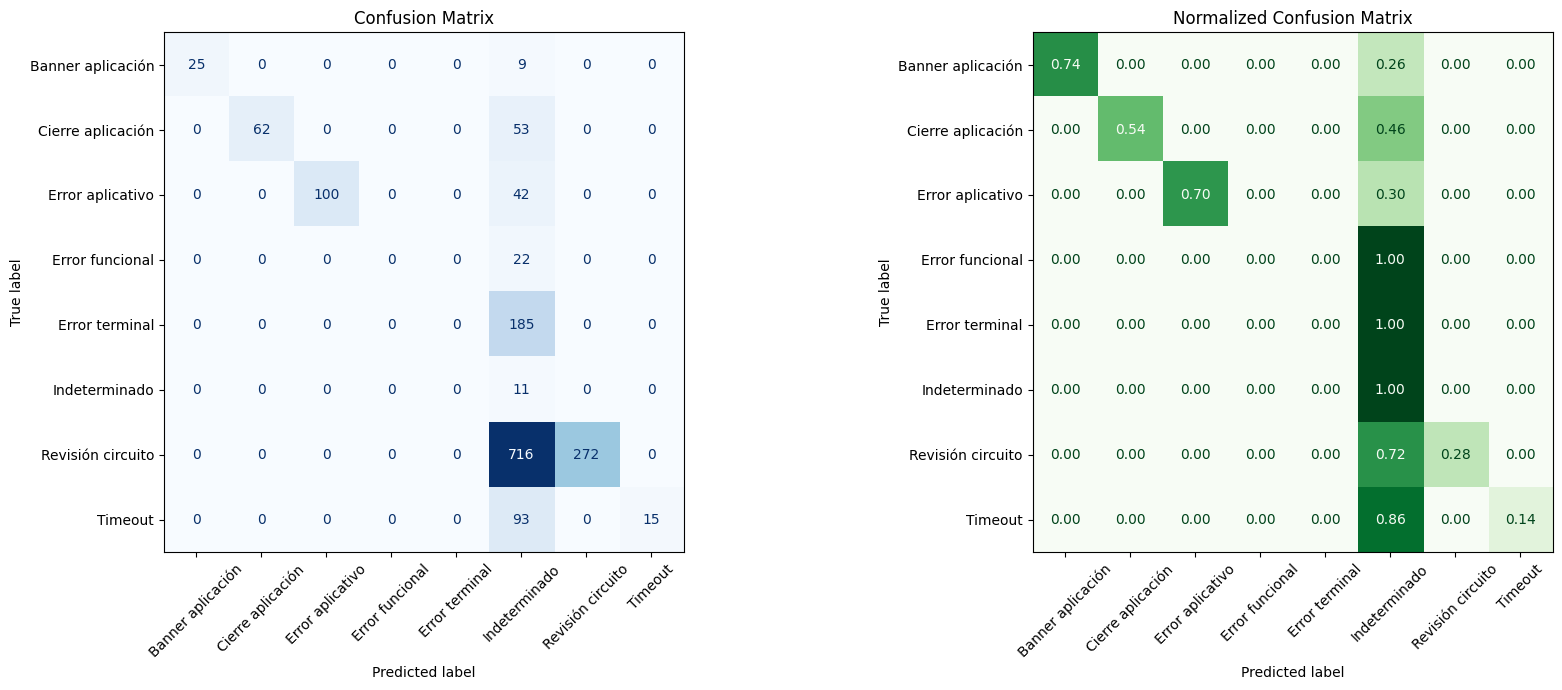

Validation rows: 1605


In [10]:
# Evaluate on VAL with the 0.80 confidence rule
X_val = vectorizer.transform(val_df['text'].fillna(''))
val_probabilities = clf.predict_proba(X_val)
raw_indices = val_probabilities.argmax(axis=1)
raw_labels = clf.classes_[raw_indices]
confidence = val_probabilities.max(axis=1)
final_labels = np.where(confidence >= CONFIDENCE_THRESHOLD, raw_labels, 'Indeterminado')

eval_df = val_df.copy().reset_index(drop=True)
eval_df['raw_prediction'] = raw_labels
eval_df['confidence'] = confidence
eval_df['prediction'] = final_labels
eval_df['is_indeterminate'] = eval_df['prediction'].eq('Indeterminado')

scores = {
    'accuracy': float(accuracy_score(eval_df['label'], eval_df['prediction'])),
    'balanced_accuracy': float(balanced_accuracy_score(eval_df['label'], eval_df['prediction'])),
    'macro_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='macro', zero_division=0)),
    'weighted_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='weighted', zero_division=0)),
    'uncertain_rate': float(eval_df['is_indeterminate'].mean()),
}

print('Scores:')
print(json.dumps(scores, indent=2))
print('\nClassification report:')
print(classification_report(eval_df['label'], eval_df['prediction'], labels=class_names, zero_division=0))

cm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names)
cm_norm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title('Confusion Matrix')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], cmap='Greens', colorbar=False, xticks_rotation=45, values_format='.2f')
axes[1].set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ocr_confusion_matrix_threshold_0p8.png', dpi=200, bbox_inches='tight')
plt.show()

print('Validation rows:', len(eval_df))

In [12]:
# Save model artifacts and validation outputs
dump(vectorizer, MODELS_DIR / 'ocr_vectorizer.joblib')
dump(clf, MODELS_DIR / 'ocr_text_classifier.joblib')
train_df.to_csv(MODELS_DIR / 'ocr_samples_train.csv', index=False)
val_df.to_csv(MODELS_DIR / 'ocr_samples_val.csv', index=False)
eval_df.to_csv(MODELS_DIR / 'ocr_validation_predictions_threshold_0p8.csv', index=False)
with open(MODELS_DIR / 'ocr_validation_scores.json', 'w', encoding='utf-8') as f:
    json.dump(scores, f, indent=2, ensure_ascii=False)
print('Saved model artifacts to', MODELS_DIR.resolve())

Saved model artifacts to C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models


In [14]:
# Inference helper with the same 0.80 confidence rule
def predict_image_class_from_ocr(image_path, confidence_threshold=0.8, vectorizer_path=MODELS_DIR / 'ocr_vectorizer.joblib', clf_path=MODELS_DIR / 'ocr_text_classifier.joblib'):
    vec = load(vectorizer_path)
    model = load(clf_path)
    text = extract_text_from_image(image_path)
    if not text:
        return {'predicted': 'Indeterminado', 'raw_prediction': 'Indeterminado', 'confidence': 0.0, 'text': ''}
    features = vec.transform([text])
    probabilities = model.predict_proba(features)[0]
    index = int(probabilities.argmax())
    raw_label = model.classes_[index]
    confidence = float(probabilities[index])
    predicted = raw_label if confidence >= confidence_threshold else 'Indeterminado'
    return {'predicted': predicted, 'raw_prediction': raw_label, 'confidence': confidence, 'text': text}

example_path = val_df.iloc[0]['path'] if len(val_df) else train_df.iloc[0]['path']
print('Example path:', example_path)
print(predict_image_class_from_ocr(example_path))

Example path: C:\Users\ibf\Desktop\TFM\Nou projecte\VAL\Banner aplicación\20260519212756_100051.png
{'predicted': 'Indeterminado', 'raw_prediction': 'Error terminal', 'confidence': 0.2247935200617537, 'text': 'Firma\n\n(1)\n\nActiva de nuevo tu firma\n\nPara poder realizar operaciones, vuelve a\nactivar la firma en este dispositivo.'}


## Notes

- The notebook uses all images under `Data/` for training and all images under `VAL/` for validation.
- Any prediction below the 0.80 confidence threshold is mapped to `Indeterminado`.
- The validation confusion matrix and score summary are saved in `Models/`.